<a href="https://colab.research.google.com/github/Akshaya24555/CodSoft/blob/main/ADlexp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Experiment - 3**

AIM:
To build and train a Convolutional Neural Network (CNN) model using the MNIST dataset to classify grayscale images of
handwritten digits (0–9).
PRE-REQUISITES:
1. Basics of Machine Learning
2. Python Programming
3. Knowledge on Numpy, Pandas, Matplotlib, TensorFlow/ Keras
4. Jupyter Notebook
5. Data Pre-Processing Techniques
6. Knowledge on Neural Networks

MNIST Dataset

*  The MNIST data set contains handwritten single digits from 0 to 9.


*  This data set can be easily accessed with Keras.


* The data set has 60,000 Training and 10,000 Testing Images.


*  Each digit image is a 28x28 Matrix.




In [ ]:
#24555A209
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

2. Importing the Built-in MNIST dataset from the Keras

In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 28, 28), (60000,))

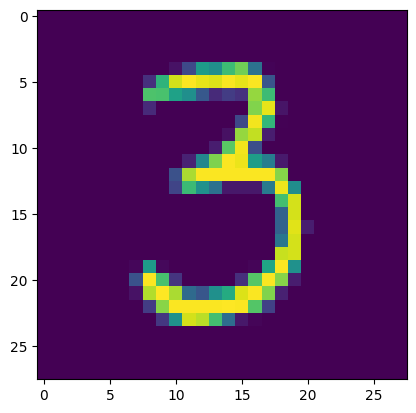

In [ ]:

X_train[10]
# Viewing the Image 8 of X_train
plt.imshow(X_train[50])

In [ ]:
y_train[50]

np.uint8(3)

3. Pre-Process the Data as required

Since, this is classification problem, we need to encode the y_train data, If not, the model assume the y label is a continuous
data

In [ ]:

from tensorflow.keras.utils import to_categorical
# Shape of the y_train
y_train.shape

(60000,)

One-hot Encoding the y

In [ ]:

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)
y_train_cat[50]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

Scaling the Data

In [ ]:
X_train.shape, X_test.shape


((60000, 28, 28), (10000, 28, 28))



* We reshape MNIST images from (28, 28) to (28, 28, 1) because Convolutional Neural Networks (CNNs) require input data to
include a channel dimension—and since MNIST images are grayscale, the channel value is 1, making the input shape
compatible with CNN layers that expect 3D input: height, width, and channels.



In [ ]:
# batch size, height, width, colour channel)
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

4. Build the Model

In [ ]:
 #import the libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

Create the Model


In [ ]:
 #Model Instance
model = Sequential()
# Convolution Layer
model.add(Conv2D(filters=32,kernel_size=(4,4),input_shape=(28,28,1),activation='relu'))
# Pooling Layer
model.add(MaxPool2D(pool_size=(2,2)))
# Flatten Layer
model.add(Flatten())
# Dense Layers (Fully Connected Layers)
model.add(Dense(128,activation='relu'))
# Output Layer (For multiclass use softmax)
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

4. Train the Model

In [ ]:
 #Train the model with Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5)
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Display model summary to verify architecture
model.summary()
# Train the model
model.fit(X_train, y_train_cat, epochs=10, validation_data=(X_test,y_test_cat), callbacks=[early_stop])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,786 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.8912 - loss: 2.0659 - val_accuracy: 0.9684 - val_loss: 0.1102
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9771 - loss: 0.0804 - val_accuracy: 0.9752 - val_loss: 0.0796
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 27ms/step - accuracy: 0.9833 - loss: 0.0550 - val_accuracy: 0.9779 - val_loss: 0.0848
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 28ms/step - accuracy: 0.9868 - loss: 0.0456 - val_accuracy: 0.9732 - val_loss: 0.0957
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9883 - loss: 0.0384 - val_accuracy: 0.9809 - val_loss: 0.0788
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 30ms/step - accuracy: 0.9910 - loss: 0.0313 - val_accuracy: 0.9798 - val_loss: 0.0921
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9924 - loss: 0.0256 - val_accuracy: 0.9794 - val_loss: 0.0888
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9949 -

5. Evaluate the Model

In [ ]:
metrics = pd.DataFrame(model.history.history)
metrics

,accuracy,loss,val_accuracy,val_loss
0,0.943633,0.484073,0.9684,0.110197
1,0.977133,0.078357,0.9752,0.079564
2,0.981833,0.060176,0.9779,0.084845
3,0.985317,0.049506,0.9732,0.095736
4,0.987917,0.040930,0.9809,0.078833
5,0.990133,0.035015,0.9798,0.092139
6,0.990900,0.032181,0.9794,0.088825
7,0.993983,0.021040,0.9809,0.112529
8,0.992867,0.027427,0.9792,0.125899
9,0.993783,0.024961,0.9810,0.128256


<Axes: >

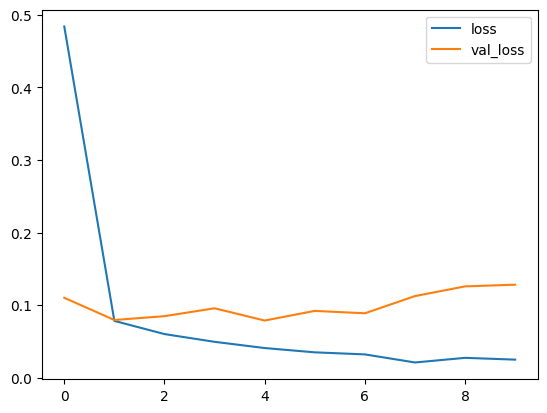

In [ ]:
 #Plot loss
metrics[['loss', 'val_loss']].plot()

<Axes: >

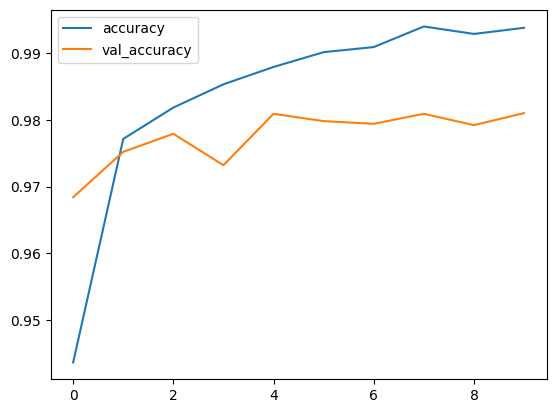

In [ ]:
 #Plot accuracy
metrics[['accuracy', 'val_accuracy']].plot()

Classification report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
# Get the Classifications on test data
y_pred = model.predict(X_test)
y_pred[0:1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([[1.7447857e-25, 4.2998497e-11, 1.7314516e-14, 6.6542671e-14,
        1.8171667e-11, 1.8214450e-19, 3.9575091e-21, 9.9999994e-01,
        2.7821404e-14, 1.9968155e-10]], dtype=float32)

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred[0:1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


array([7])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.99      0.97      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
print(confusion_matrix(y_test,y_pred))

[[ 971    0    2    0    0    0    4    0    1    2]
 [   0 1122    1    4    1    0    3    1    3    0]
 [   1    2 1011    4    2    0    0    9    1    2]
 [   0    0    2  999    0    5    0    2    2    0]
 [   2    2    0    0  954    0    3    2    2   17]
 [   3    1    0    9    0  867    7    0    4    1]
 [   6    4    0    1    1    3  940    0    3    0]
 [   0    2    2    7    0    0    0 1008    0    9]
 [   3    1    3    6    0    1    1    2  948    9]
 [   0    4    0    2    5    3    1    3    1  990]]


Classiying the new image

In [ ]:
from tensorflow.keras.preprocessing import image
from PIL import Image
# Convert to grayscale
new_image = Image.open('/content/no.png').convert('L')

In [ ]:
 #Resize to 28x28
new_image = new_image.resize((28, 28))
new_image

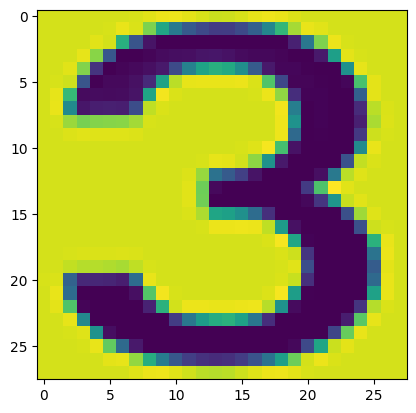

In [ ]:
 #Convert to NumPy array and normalize
img_array = np.array(new_image)
img_array = img_array / 255.0
plt.imshow(img_array)

In [ ]:
img_array = img_array.reshape(1, 28, 28, 1)

pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [ ]:
np.argmax(pred, axis=1)

array([1])

RESULT:
A Convolutional Neural Network (CNN) model was successfully developed and trained using the MNIST dataset to classify
grayscale images of handwritten digits (0–9) and the model achieved high accuracy and able to correctly predict digits from
custom input images